# Setup, Libraries, and Constants

In [1]:
# setup the venv
# run this cell first, then refresh the page and select the kernel.
# there is no harm in running this after setting it up, inly a few seconds
!bash /home/hcr64/Pinyon-Detection/shells/jupyter_kernel_env.sh

Installed kernelspec open3d_env in /home/hcr64/.local/share/jupyter/kernels/open3d_env


In [2]:
import sys

# ── path setup ──────────────────────────────────────────────────────────────
# Each entry below adds a specific directory so its modules can be imported
# directly (bare name), WITHOUT triggering that directory's __init__.py and
# its full dependency chain. This avoids the two-different-"functions"-
# packages name collision entirely — never `import functions` itself.
sys.path.insert(0, "/home/hcr64/Pinyon-Detection")                                  # global_files/
sys.path.insert(0, "/home/hcr64/Pinyon-Detection/modelling/functions")              # feature_config.py, standalone
sys.path.insert(0, "/home/hcr64/Pinyon-Detection/modelling/functions/features")     # diagnose_cluster_bimodality.py — adjust if saved elsewhere
sys.path.insert(0, "/home/hcr64/Pinyon-Detection/clustering/functions/detection")   # split_large_clusters.py — adjust if saved elsewhere

# ── third-party ────────────────────────────────────────────────────────────
from pyntcloud import PyntCloud
from plyfile import PlyData
import numpy as np
import os
import pandas as pd
import random
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# ── project: paths + cached dataframes/clusters ───────────────────────────
from global_files import load_clusters, load_dataframes, get_paths, save_clusters

# ── project: feature list (standalone, no torch/xgboost/lightgbm pulled in) ─
from feature_config import FEATURES

# ── project: bimodality diagnostics ────────────────────────────────────────
from diagnose_cluster_bimodality import (
    diagnose_all_clusters,
    diagnose_cluster_bimodality,
    calibrate_thresholds,
    explain_why_not_flagged,
    get_color_spatial_override_candidates,
    get_flagged_cluster_paths,
    get_flagged_indices_from_sources,
)

# ── project: colour-augmented splitting ────────────────────────────────────
sys.path.insert(0, "/home/hcr64/Pinyon-Detection/clustering/functions/detection")  # wherever you actually saved this file
from split_large_clusters import split_large_clusters, find_density_peaks, filter_cluster

# ── paths + data ────────────────────────────────────────────────────────────

# paths and other constants
TRIAL_NAME      = 'Sunset_sfm_trial'
PATHS = get_paths( TRIAL_NAME )

DATAFRAMES_PATH = PATHS['Dataframes']
CLUSTERS_PATH   = PATHS['Clusters']

df_clusters, df_deep_clusters = load_dataframes( DATAFRAMES_PATH )
clusters = load_clusters( CLUSTERS_PATH )

df_pred = pd.read_csv(DATAFRAMES_PATH + "predictions.csv")
df_pred.head()

# confirm
print( PATHS['Clusters'] )

print(len(clusters), len(df_clusters))  # sanity check — should match; if not, see the sync-mismatch note from earlier

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Loaded df_clusters      (2015 rows) ← /home/hcr64/Pinyon-Detection/trial_data/Sunset_sfm_trial/dataframes/clusters.csv
Loaded df_deep_clusters (2015 rows) ← /home/hcr64/Pinyon-Detection/trial_data/Sunset_sfm_trial/dataframes/deep_clusters.csv
/scratch/hcr64/Pinyon-Detection/data/Sunset_sfm_trial/clusters/
2015 2015


In [3]:
# paths and other constants
TRIAL_NAME      = 'Sunset_sfm_trial'
PATHS = get_paths( TRIAL_NAME )

DATAFRAMES_PATH = PATHS['Dataframes']
CLUSTERS_PATH   = PATHS['Clusters']

df_pred = pd.read_csv(DATAFRAMES_PATH + "predictions.csv")
df_pred.head()

# confirm
print( PATHS['Clusters'] )


/scratch/hcr64/Pinyon-Detection/data/Sunset_sfm_trial/clusters/


# Functions

### Old Visualise pointlcoud function

In [4]:
# function to draw a window with a pointcloud in it
def visualize_pointcloud(pcd_path, pcd=None, point_size=2, background_color="black"):

    plydata = PlyData.read(pcd_path)
    vertex = plydata['vertex']

    points = np.vstack([vertex['x'], vertex['y'], vertex['z']]).T

    # use color if available, otherwise default to white
    vertex_names = vertex.data.dtype.names
    if 'red' in vertex_names and 'green' in vertex_names and 'blue' in vertex_names:
        r = vertex['red']
        g = vertex['green']
        b = vertex['blue']
        color_str = [f"rgb({int(r_)},{int(g_)},{int(b_)})" for r_, g_, b_ in zip(r, g, b)]
    else:
        color_str = "white"

    fig = go.Figure(data=[go.Scatter3d(
        x=points[:, 0],
        y=points[:, 1],
        z=points[:, 2],
        mode="markers",
        marker=dict(
            size=point_size,
            color=color_str,
        )
    )])

    fig.update_layout(
        scene=dict(bgcolor=background_color),
        paper_bgcolor="black",
    )

    fig.show()

### New Visualise Pointclouds Function

In [5]:
import numpy as np
import open3d as o3d
import plotly.graph_objects as go
from plyfile import PlyData

# distinct colours used when color_by_source=True
_PALETTE = ["#e6194b", "#3cb44b", "#4363d8", "#f58231",
            "#911eb4", "#46f0f0", "#f032e6", "#bcf60c"]

def _points_and_colors(src):
    """Return (N,3) points and (N,3) colours in 0-255 (or None) from a path or PointCloud."""
    if isinstance(src, o3d.geometry.PointCloud):
        points = np.asarray(src.points)
        # Open3D stores colours as floats in 0-1
        colors = np.asarray(src.colors) * 255 if src.has_colors() else None
    else:
        vertex = PlyData.read(str(src))["vertex"]
        points = np.vstack([vertex["x"], vertex["y"], vertex["z"]]).T
        names = vertex.data.dtype.names
        if {"red", "green", "blue"} <= set(names):
            # .ply files written by Open3D store colours as 0-255
            colors = np.vstack([vertex["red"], vertex["green"], vertex["blue"]]).T
        else:
            colors = None
    return points, colors

def visualize_pointcloud(src, point_size=2, background_color="black",
                         color_by_source=False, max_points=None):
    """
    src: a .ply path, an o3d PointCloud, or a list/tuple of either.
    color_by_source: give each item in a list one flat colour, to compare split pieces.
    max_points: randomly subsample each cloud to this many points for faster rendering.
    """
    sources = list(src) if isinstance(src, (list, tuple)) else [src]
    rng = np.random.default_rng(0)
    traces = []

    for i, s in enumerate(sources):
        points, colors = _points_and_colors(s)

        if max_points is not None and len(points) > max_points:
            keep = rng.choice(len(points), max_points, replace=False)
            points = points[keep]
            colors = colors[keep] if colors is not None else None

        if color_by_source or colors is None:
            marker_color = _PALETTE[i % len(_PALETTE)] if color_by_source else "white"
        else:
            marker_color = [f"rgb({int(r)},{int(g)},{int(b)})" for r, g, b in colors]

        traces.append(go.Scatter3d(
            x=points[:, 0], y=points[:, 1], z=points[:, 2],
            mode="markers",
            marker=dict(size=point_size, color=marker_color),
            name=f"piece {i} ({len(points)} pts)",
        ))

    fig = go.Figure(data=traces)
    fig.update_layout(scene=dict(bgcolor=background_color, aspectmode="data"),
                      paper_bgcolor="black",
                      legend=dict(font=dict(color="white")))
    fig.show()

### In Testing, use after splitting

In [22]:
import numpy as np
from scipy.spatial import KDTree
from sklearn.mixture import GaussianMixture

def _colour_features(col, feature="logratio"):
    """col: (N,3) RGB in 0-1."""
    if feature == "logratio":
        c = np.clip(col, 1 / 255, None)      # avoid log(0) on black points
        return np.column_stack([np.log(c[:, 0] / c[:, 1]),    # log(r/g)
                                np.log(c[:, 2] / c[:, 1])])   # log(b/g)
    # chromaticity, as before
    return col / (col.sum(axis=1, keepdims=True) + 1e-6)

def refine_two_way_split(pieces, feature="logratio", color_weight=25.0,
                         z_weight=0.0, dark_percentile=30,
                         smooth_k=15, smooth_iters=2, vote_k=10):
    assert len(pieces) == 2
    allpcd = pieces[0] + pieces[1]
    pts, col = np.asarray(allpcd.points), np.asarray(allpcd.colors)
    init = np.r_[np.zeros(len(pieces[0].points), int),
                 np.ones(len(pieces[1].points), int)]

    brightness = col.sum(axis=1) / 3
    reliable = brightness > np.percentile(brightness, dark_percentile)

    feats = np.column_stack([pts[:, :2],
                             color_weight * _colour_features(col, feature),
                             z_weight * pts[:, 2:3]])

    # fit the colour model on well-lit points only
    means = np.array([feats[reliable & (init == i)].mean(axis=0) for i in (0, 1)])
    gmm = GaussianMixture(2, means_init=means, covariance_type="full",
                          random_state=0).fit(feats[reliable])

    labels = np.empty(len(pts), int)
    labels[reliable] = gmm.predict(feats[reliable])

    # dark points take the majority label of nearby well-lit points in 3D
    tree = KDTree(pts[reliable])
    _, nbrs = tree.query(pts[~reliable], k=vote_k)
    labels[~reliable] = (labels[reliable][nbrs].mean(axis=1) > 0.5).astype(int)

    # final spatial smoothing over everything
    _, nbrs_all = KDTree(pts).query(pts, k=smooth_k)
    for _ in range(smooth_iters):
        labels = (labels[nbrs_all].mean(axis=1) > 0.5).astype(int)

    moved = (labels != init).sum()
    print(f"[{feature}, w={color_weight}] {(~reliable).sum()} dark points relabelled; "
          f"{moved} points changed side ({100 * moved / len(pts):.1f}%)")
    return [allpcd.select_by_index(np.where(labels == i)[0]) for i in (0, 1)]

# Get predictions and Missclassifications

In [7]:
# get the cluster ids of mismatched clusters
df_mismatch = pd.read_csv(PATHS['Dataframes'] + 'pinyon_misclassification_report.csv')

id_col = "file" if "file" in df_mismatch.columns else df_mismatch.columns[0]
mismatched_ids = df_mismatch[id_col].astype(int).tolist()

print(f"{len(mismatched_ids)} mismatched clusters")
print(mismatched_ids)
cluster = 0

7 mismatched clusters
[1484, 1399, 1375, 1341, 1006, 545, 1745]


In [8]:
# get confident pinyons
df_pred = pd.read_csv(DATAFRAMES_PATH + "predictions.csv")

#df_confident = df_pred[df_pred["high_confidence"]]        # only >80% confident
df_pinyon_confident = df_pred[(df_pred["predicted_label"] == "pinyon") & (df_pred["prob_pinyon"] > 0.9)]

# look at it
len( df_pinyon_confident )
df_pinyon_confident.head()

,file,predicted_label,prob_juniper,prob_pinyon,prob_ponderosa,prob_drought_susceptible,prob_drought_tolerant,prob_combined_juniper,prob_combined_pinyon_susceptible,prob_combined_pinyon_tolerant,prob_combined_ponderosa,semi_label,semi_confidence,x_pos,y_pos,height,radius,n_points,Name,label_distance
1,1,pinyon,2.459471e-02,0.975210,1.953800e-04,NaN,NaN,0.194189,0.354958,0.378747,0.072106,uncertain,0.552466,461735.608,3917620.407,3.772,4.427,433,unknown,inf
2,2,pinyon,3.191414e-03,0.996452,3.565820e-04,NaN,NaN,0.112511,0.352627,0.473553,0.061309,pinyon,0.923645,461607.548,3917620.457,2.995,2.082,286,unknown,inf
3,3,pinyon,2.922221e-02,0.969778,9.995175e-04,NaN,NaN,0.120212,0.230088,0.610576,0.039123,pinyon,0.970896,461842.005,3917620.168,2.938,2.775,300,unknown,inf
7,7,pinyon,1.412988e-09,1.000000,4.264664e-08,NaN,NaN,0.085171,0.639918,0.195269,0.079642,pinyon,0.984212,461651.557,3917619.614,3.709,2.336,607,unknown,inf
8,8,pinyon,2.524722e-06,0.999997,4.902083e-07,NaN,NaN,0.143213,0.530810,0.284279,0.041698,pinyon,0.984217,461632.790,3917617.984,4.442,3.267,1207,unknown,inf


In [9]:
from random import *
# get the path of desired pointcloud
cluster_id = int(df_pinyon_confident["file"].sample(1).iloc[0])
mm_id = mismatched_ids[ 1 ]
cluster_id = mm_id

#cluster_id = df_pinyon_confident.()['file']
print( cluster_id )
PLY_PATH = PATHS['Clusters'] +  f"cluster{cluster_id}.ply"   # change per cluster
# cluster += 1

# call the function on it
print( PLY_PATH )
visualize_pointcloud( PLY_PATH )

1399
/scratch/hcr64/Pinyon-Detection/data/Sunset_sfm_trial/clusters/cluster1399.ply


In [10]:
# try to split cluster by x y and color
chosen_cluster = clusters[mm_id]

points = np.asarray(chosen_cluster.points)
find_density_peaks( points, colors=True, k=30, min_peak_distance=1.0,
                       min_density_ratio=2.5, use_color=False,
                       color_weight=10.0)


([],
 array([6.39570833, 3.41421289, 7.29928461, ..., 5.16259493, 4.54450415,
        2.66558774], shape=(28754,)))

# Splitting Overlapping Clusters

In [11]:
new_clusters = split_large_clusters(
    [chosen_cluster],
    min_points=100,
    max_radius=0.0,              # or leave high and use force_check_indices={0}
    min_peak_distance=1.0,       # bandwidth in the combined XY+colour space
    k=50,
    min_density_ratio=1.5,
    use_color=True,
    color_weight=30.0,           # sweep 10 / 30 / 60 / 100
    color_channels=("chroma_g", "chroma_r", "chroma_b"),
)

Found 6 density peaks (XY+colour) in cluster (radius=4.10m), attempting Mean Shift split...
Mean Shift split cluster (radius=4.10m, XY+colour) into 7 sub-clusters
Clusters before splitting: 1
Clusters after splitting:  7


In [12]:
# investigate new clusters
for i, c in enumerate(new_clusters):
    pts = np.asarray(c.points)
    col = np.asarray(c.colors)
    print(i, len(pts), pts[:, :2].mean(axis=0).round(2), col.mean(axis=0).round(3))

0 12340 [ 461450.57 3917126.77] [0.424 0.444 0.314]
1 9892 [ 461448.56 3917126.69] [0.415 0.43  0.322]
2 3289 [ 461445.59 3917126.04] [0.368 0.401 0.242]
3 1744 [ 461447.43 3917127.98] [0.265 0.289 0.243]
4 813 [ 461444.66 3917127.17] [0.198 0.229 0.161]
5 318 [ 461445.97 3917127.39] [0.088 0.117 0.108]
6 358 [ 461444.95 3917127.78] [0.053 0.09  0.076]


In [13]:
# find best params for split_large_clusters
# can take a while, do not need to run every time
""" for bw in (1.0, 1.5, 2.0, 3.0):
    for w in (10, 20, 30):
        out = split_large_clusters([chosen_cluster], min_points=100, max_radius=0.0,
                                   min_peak_distance=bw, k=200, min_density_ratio=1.5,
                                   use_color=True, color_weight=w)
        print(bw, w, len(out), sorted(len(np.asarray(c.points)) for c in out)[::-1][:4]) """

' for bw in (1.0, 1.5, 2.0, 3.0):\n    for w in (10, 20, 30):\n        out = split_large_clusters([chosen_cluster], min_points=100, max_radius=0.0,\n                                   min_peak_distance=bw, k=200, min_density_ratio=1.5,\n                                   use_color=True, color_weight=w)\n        print(bw, w, len(out), sorted(len(np.asarray(c.points)) for c in out)[::-1][:4]) '

In [14]:
new_clusters = split_large_clusters([chosen_cluster], min_points=100, max_radius=0.0,
                                    min_peak_distance=1.5, k=200, min_density_ratio=1.5,
                                    use_color=True, color_weight=15)
for i, c in enumerate(new_clusters):
    pts, col = np.asarray(c.points), np.asarray(c.colors)
    print(i, len(pts), "XY", pts[:, :2].mean(axis=0).round(2),
          "Z", pts[:, 2].min().round(1), pts[:, 2].max().round(1),
          "RGB", col.mean(axis=0).round(3))

Found 3 density peaks (XY+colour) in cluster (radius=4.10m), attempting Mean Shift split...
Mean Shift split cluster (radius=4.10m, XY+colour) into 2 sub-clusters
Clusters before splitting: 1
Clusters after splitting:  2
0 20672 XY [ 461449.86 3917126.83] Z 1812.1 1820.7 RGB [0.408 0.426 0.309]
1 8082 XY [ 461446.19 3917126.59] Z 1812.1 1818.6 RGB [0.345 0.372 0.256]


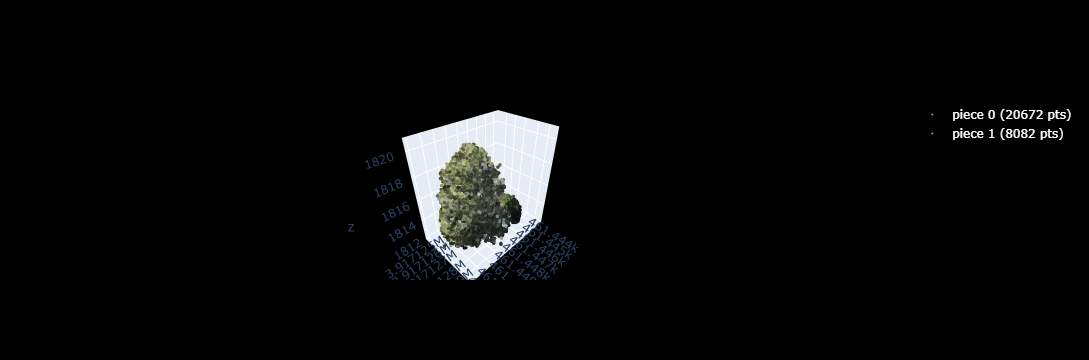

In [15]:
# look at the two halves
new_clusters
visualize_pointcloud( new_clusters )

Found 3 density peaks (XY+colour) in cluster (radius=4.10m), attempting Mean Shift split...
Mean Shift split cluster (radius=4.10m, XY+colour) into 2 sub-clusters
Clusters before splitting: 1
Clusters after splitting:  2
[logratio, w=14] 1152 dark points relabelled; 2332 points changed side (8.1%)


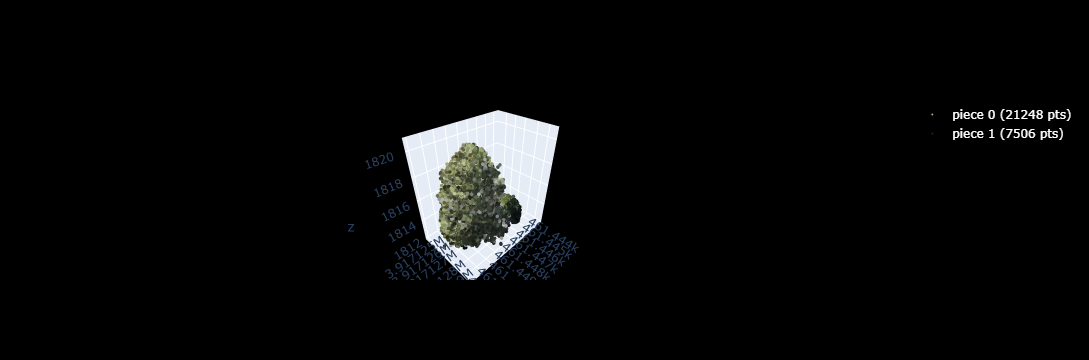

In [28]:
pieces = split_large_clusters([chosen_cluster], min_points=100, max_radius=0.0,
                              min_peak_distance=1.5, k=200, min_density_ratio=1.5,
                              use_color=True, color_weight=15)
refined = refine_two_way_split(pieces, z_weight=1,smooth_k=40, color_weight=14, dark_percentile=4, vote_k=50)
visualize_pointcloud(refined, color_by_source=False)

In [17]:
"""labeled_clusters = load_clusters(PATHS['Labeled_clusters'])

df_diag = diagnose_all_clusters(
    labeled_clusters,
    save_path=PATHS['Images'] + 'bimodality_diagnostics/',
)

flagged = df_diag.loc[df_diag["color_bimodal_spatial_unimodal"], "file"].unique()
print(sorted(flagged)) """

'labeled_clusters = load_clusters(PATHS[\'Labeled_clusters\'])\n\ndf_diag = diagnose_all_clusters(\n    labeled_clusters,\n    save_path=PATHS[\'Images\'] + \'bimodality_diagnostics/\',\n)\n\nflagged = df_diag.loc[df_diag["color_bimodal_spatial_unimodal"], "file"].unique()\nprint(sorted(flagged)) '

In [18]:
from diagnose_cluster_bimodality import calibrate_thresholds
df_clusters, df_deep_clusters = load_dataframes(PATHS['Dataframes']) 

comparison_indices = [1399, 1375, 1483, 545, 1006, 1744] + list(df_clusters.sample(15, random_state=1)["file"])
df_cal = calibrate_thresholds(clusters, comparison_indices)

Loaded df_clusters      (2015 rows) ← /home/hcr64/Pinyon-Detection/trial_data/Sunset_sfm_trial/dataframes/clusters.csv
Loaded df_deep_clusters (2015 rows) ← /home/hcr64/Pinyon-Detection/trial_data/Sunset_sfm_trial/dataframes/deep_clusters.csv

══════════════════════════════════════════════════════════════════════
  RAW CALIBRATION STATS (no thresholds applied)
══════════════════════════════════════════════════════════════════════
 file  feature  n_points  delta_bic  separation_in_std  intercentroid_distance_m  separation_ratio    group_sizes
  102 chroma_g       225  -2.915910           1.878723                  1.087483          0.929014     (112, 113)
  102 chroma_r       225  -3.437217           0.444415                  0.876306          0.622658      (32, 193)
  102 chroma_b       225  -9.293234           2.094492                  0.841207          0.696892     (108, 117)
  111 chroma_b        79   1.074696           2.748611                  0.503121          0.980499       (44, 

In [19]:
from diagnose_cluster_bimodality import explain_why_not_flagged

explain_why_not_flagged(
    clusters,
    [1399, 1375, 1483, 545, 1006, 1744],
    max_radius=4.25,   # from pinyons.sh, so you can see the production-gate context too
)


─────────────────────────────────────────────────────────────────
  cluster 1399  (n_points=28754, radius=4.10m, n_spatial_peaks=9)
  radius vs max_radius=4.25: ⚠ at or below max_radius — production split_large_clusters() would SKIP this cluster entirely (gate 1)
─────────────────────────────────────────────────────────────────
  chroma_g     ✅ bimodal AND spatially separated  (delta_bic=93.3, xy_sep=1.85m, ratio=0.85, need ratio>=0.75 and dist>=0.3m)
  chroma_r     ✅ bimodal AND spatially separated  (delta_bic=378.0, xy_sep=1.65m, ratio=0.83, need ratio>=0.75 and dist>=0.3m)
  chroma_b     ❌ not bimodal  (delta_bic=-22.3, need >= 10.0;  separation=0.94σ, need >= 1.0)

  ⚠  colour signal found and spatially separated, but n_spatial_peaks=9 already >= 2 — this diagnostic's flag specifically targets cases XY density MISSES. XY already suspects two trees here, so the real question is why the production split_large_clusters() didn't already separate this cluster (Mean Shift not converging

In [20]:
from diagnose_cluster_bimodality import get_color_spatial_override_candidates
#from split_large_clusters import split_large_clusters

override_indices = get_color_spatial_override_candidates(
    clusters, [1399, 1375, 1483, 545, 1006, 1744]
)
# expect [1399, 1375, 1483] back, given what you already saw

test_split = split_large_clusters(
    [clusters[i] for i in override_indices],  # just these 3, for a fast isolated test
    min_points=40, max_radius=4.25, min_peak_distance=3.0,
    use_color=True, color_weight=10.0,
    force_check_indices=set(range(len(override_indices))),  # indices within this small sublist
    save_pre_split_path="/scratch/hcr64/test_override_split/",
)

  cluster 1399: override candidate (strongest feature=chroma_g, ratio=0.85)
  cluster 1375: override candidate (strongest feature=chroma_b, ratio=0.85)
  cluster 1483: override candidate (strongest feature=chroma_r, ratio=0.95)

  3/6 clusters qualify as radius-gate override candidates
Cluster 0 (radius=2.26m, below max_radius=4.25) force-checked via force_check_indices override
Found 2 density peaks (XY+colour) in cluster (radius=2.26m), attempting Mean Shift split...
Cluster 1 (radius=4.10m, below max_radius=4.25) force-checked via force_check_indices override
Found 2 density peaks (XY+colour) in cluster (radius=4.10m), attempting Mean Shift split...
Cluster 2 (radius=3.86m, below max_radius=4.25) force-checked via force_check_indices override
Found 3 density peaks (XY+colour) in cluster (radius=3.86m), attempting Mean Shift split...
All 0 clusters saved to /scratch/hcr64/test_override_split/ with descriptive names
Saved 0 pre-split clusters to /scratch/hcr64/test_override_split/
for

In [21]:
from diagnose_cluster_bimodality import get_flagged_cluster_paths

df_diag = diagnose_all_clusters(
    clusters,
    delta_bic_threshold=10.0,
    separation_threshold=1.0,
    spatial_separation_ratio=0.75,
    min_intercentroid_m=0.3,
    min_spatial_group_size=15,
    save_path=PATHS['Images'] + 'bimodality_diagnostics/',
)
flagged_paths = get_flagged_cluster_paths(df_diag, PATHS['Clusters'])
print(flagged_paths)

Running bimodality diagnostic on all 2015 clusters — this checks every cluster in the trial, expect more candidates than a targeted run and treat flags as leads for visual inspection, not confirmed merges.

  ⚠  cluster 2 flagged (n_points=286, n_spatial_peaks=1, strongest feature=chroma_b)
  ⚠  cluster 16 flagged (n_points=225, n_spatial_peaks=1, strongest feature=chroma_b)
  ⚠  cluster 18 flagged (n_points=359, n_spatial_peaks=1, strongest feature=chroma_g)
  ⚠  cluster 21 flagged (n_points=283, n_spatial_peaks=1, strongest feature=chroma_b)
  ⚠  cluster 34 flagged (n_points=99, n_spatial_peaks=1, strongest feature=chroma_r)
  ⚠  cluster 38 flagged (n_points=244, n_spatial_peaks=1, strongest feature=chroma_g)
  ⚠  cluster 45 flagged (n_points=121, n_spatial_peaks=1, strongest feature=chroma_r)
  ⚠  cluster 53 flagged (n_points=256, n_spatial_peaks=1, strongest feature=chroma_g)
  ⚠  cluster 58 flagged (n_points=65, n_spatial_peaks=1, strongest feature=chroma_g)
  ⚠  cluster 59 flagge

KeyboardInterrupt: 

In [ ]:
  flagged = df_diag.loc[df_diag["color_bimodal_spatial_unimodal"], "file"].unique()
  print(sorted(flagged))

In [ ]:
flagged_indices = sorted(df_diag.loc[df_diag["color_bimodal_spatial_unimodal"], "file"].unique().tolist())
print(len(flagged_indices))

confirmed = {1399, 1375, 1483}   # passed color+spatial gates in your earlier explain_why_not_flagged run
rejected  = {545, 1006, 1744}    # failed the spatial gate or found no bimodality

print("known confirmed present:", confirmed & set(flagged_indices))   # should be all 3
print("known rejected present:", rejected & set(flagged_indices))     # should be none

In [ ]:
cluster=0

In [ ]:
flagged_indices
cluster_id = flagged_indices[cluster]
PLY_PATH = PATHS['Clusters'] +  f"cluster{cluster_id}.ply"   # change per cluster
cluster += 1

# call the function on it
print( PLY_PATH )
visualize_pointcloud( PLY_PATH )

In [ ]:
MAX_RADIUS = 4.25  # from pinyons.sh

below_gate, above_gate = [], []
for idx in flagged_indices:
    pcd = clusters[idx]
    aabb = pcd.get_axis_aligned_bounding_box()
    radius = max((aabb.max_bound - aabb.min_bound)[:2]) / 2
    (below_gate if radius <= MAX_RADIUS else above_gate).append(idx)

print(f"{len(below_gate)} flagged clusters sit at/below max_radius — "
      f"production split_large_clusters() skips these entirely (gate 1)")
print(f"{len(above_gate)} flagged clusters sit above max_radius — "
      f"production would already attempt a split on these; worth checking "
      f"why it isn't succeeding (Mean Shift not converging to 2 modes, or "
      f"filter_cluster rejecting the sub-clusters)")

In [ ]:
from diagnose_cluster_bimodality import get_flagged_cluster_paths
import random

paths = get_flagged_cluster_paths(df_diag, PATHS['Clusters'])
sample = random.sample(paths, min(15, len(paths)))
print(sample)